# Real Dollars — Joining HHS OCR Enforcement Actions to Breaches

Everything else in this project estimates financial impact from external benchmarks. This
notebook adds the only **official** dollar figures that exist: HIPAA settlements and civil
money penalties published by HHS OCR on its
[Resolution Agreements page](https://www.hhs.gov/hipaa/for-professionals/compliance-enforcement/agreements/index.html).

**Dataset honesty:**
- `data/ocr_enforcement.csv` contains 65 enforcement actions where the penalty amount is stated
  in the official HHS page listing (2009–2026, ~$126M). OCR reports 152 total actions worth
  ~$144.9M — the remainder are mostly small right-of-access cases with amounts not stated in
  listing titles, and are excluded rather than guessed.
- Entity matching is **organization-level, not incident-level**: an enforcement action is linked
  to the same-named organization's largest in-window breach, which is usually — but not always —
  the incident that triggered the action.
- The automated match was manually audited; 8 false positives from generic names
  (e.g. "OS, Inc.", "Regional Medical Center") are explicitly excluded below.

In [1]:
import re
from difflib import SequenceMatcher

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

breaches = pd.read_csv("../data/breach_clean.csv")
breaches["Individuals Affected"] = pd.to_numeric(breaches["Individuals Affected"], errors="coerce")
enforcement = pd.read_csv("../data/ocr_enforcement.csv", parse_dates=["date"])
print(f"{len(enforcement)} enforcement actions, ${enforcement.amount_usd.sum()/1e6:.1f}M total")

65 enforcement actions, $126.2M total


## 1. Enforcement actions over time

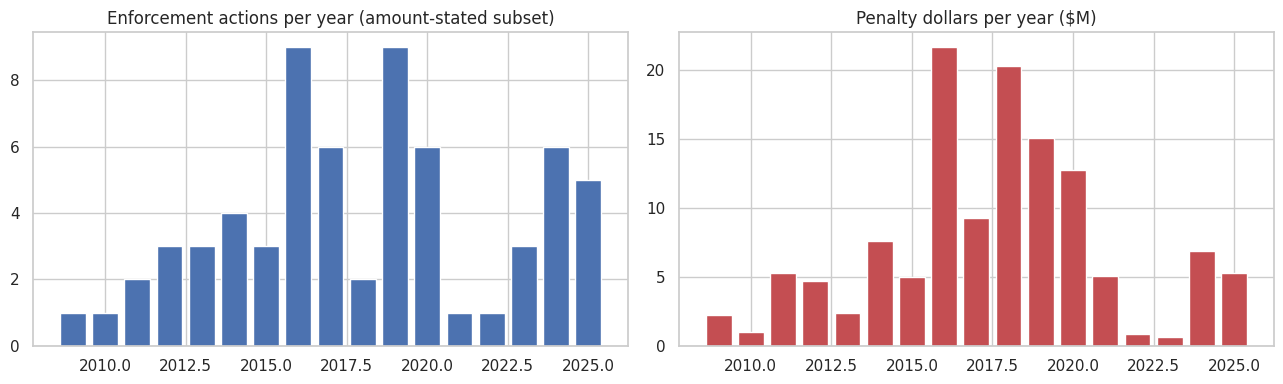

,date,entity,amount_usd,action_type
31,2018-10-15,Anthem,16000000,settlement
17,2020-09-25,Premera Blue Cross,6850000,settlement
40,2016-08-04,Advocate Health Care Network,5550000,settlement
37,2017-02-16,Memorial Healthcare System,5500000,settlement
15,2021-01-15,Excellus Health Plan,5100000,settlement
52,2014-05-07,New York-Presbyterian Hospital and Columbia Un...,4800000,settlement
10,2024-02-06,Montefiore Medical Center,4750000,settlement
32,2018-06-18,MD Anderson Cancer Center,4300000,civil_money_penalty


In [2]:
by_year = enforcement.assign(year=enforcement["date"].dt.year).groupby("year")["amount_usd"].agg(["count", "sum"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(by_year.index, by_year["count"], color="#4C72B0")
axes[0].set_title("Enforcement actions per year (amount-stated subset)")
axes[1].bar(by_year.index, by_year["sum"] / 1e6, color="#C44E52")
axes[1].set_title("Penalty dollars per year ($M)")
plt.tight_layout(); plt.show()

enforcement.nlargest(8, "amount_usd")[["date", "entity", "amount_usd", "action_type"]]

## 2. Match enforcement actions to breach reports

Rules: normalized-name comparison (suffixes stripped), requiring either a long substring match,
a 2+ token subset, or >= 0.90 string similarity; the breach must precede the enforcement action
by 0–9 years. Manually audited exclusions remove generic-name false positives.

In [3]:
def norm(s: str) -> str:
    s = str(s).lower()
    s = re.sub(r"\b(inc|llc|llp|ltd|corp|corporation|company|co|pc|pa|dba|d/b/a|the)\b", "", s)
    return re.sub(r"\s+", " ", re.sub(r"[^a-z0-9 ]", " ", s)).strip()

# manually audited false positives (generic names that slip past the rules)
EXCLUDE_BREACH_MATCH = {"os, inc.", "university health", "health care service corporation",
                        "new", "washington university school of medicine", "centra",
                        "regional medical center", "blue cross blue shield"}

breaches["_n"] = breaches["Name of Covered Entity"].map(norm)

def score(en: str, x: str) -> float:
    if min(len(en), len(x)) >= 10 and (en in x or x in en):
        return 1.0
    et, xt = set(en.split()), set(x.split())
    small = et if len(et) <= len(xt) else xt
    if len(small) >= 2 and len(" ".join(small)) >= 10 and (et <= xt or xt <= et):
        return 0.95
    return SequenceMatcher(None, en, x).ratio()

rows = []
for _, act in enforcement.iterrows():
    en, ey = norm(act["entity"]), act["date"].year
    cand = breaches[(breaches["Year"] <= ey) & (breaches["Year"] >= ey - 9)].copy()
    cand["_s"] = cand["_n"].apply(lambda x: score(en, x))
    cand = cand[(cand["_s"] >= 0.90) &
                (~cand["Name of Covered Entity"].str.lower().isin(EXCLUDE_BREACH_MATCH))]
    if len(cand):
        best = cand.sort_values(["_s", "Individuals Affected"], ascending=False).iloc[0]
        rows.append({"enforcement_entity": act["entity"], "enforcement_date": act["date"],
                     "amount_usd": act["amount_usd"], "action_type": act["action_type"],
                     "source_url": act["source_url"],
                     "breach_entity": best["Name of Covered Entity"],
                     "breach_year": best["Year"],
                     "individuals_affected": best["Individuals Affected"],
                     "breach_type": best["Type of Breach"], "match_score": round(best["_s"], 2)})

matched = pd.DataFrame(rows)
print(f"{len(matched)} of {len(enforcement)} enforcement actions matched to a reported breach")
matched[["enforcement_entity", "amount_usd", "breach_entity", "breach_year",
         "individuals_affected"]].sort_values("amount_usd", ascending=False).head(15)

42 of 65 enforcement actions matched to a reported breach


,enforcement_entity,amount_usd,breach_entity,breach_year,individuals_affected
23,Anthem,16000000,Anthem Inc.,2015,78800000.0
13,Premera Blue Cross,6850000,Premera Blue Cross,2015,11000000.0
30,Advocate Health Care Network,5550000,Advocate Health Care,2010,812.0
27,Memorial Healthcare System,5500000,Memorial Healthcare System,2012,105646.0
11,Excellus Health Plan,5100000,"Excellus Health Plan, Inc.",2015,9358891.0
7,Montefiore Medical Center,4750000,Montefiore Medical Center,2020,76068.0
24,MD Anderson Cancer Center,4300000,The University of Texas MD Anderson Cancer Center,2013,29021.0
33,Feinstein Institute for Medical Research,3900000,The Feinstein Institute for Medical Reserch,2012,13000.0
35,Triple-S Management Corporation,3500000,Puerto Rico Department of Health - Triple S Ma...,2010,475000.0
3,Solara Medical Supplies LLC,3000000,"Solara Medical Supplies, LLC",2019,114007.0


In [4]:
matched.to_csv("../data/breach_penalties.csv", index=False)
print("saved ../data/breach_penalties.csv")

saved ../data/breach_penalties.csv


## 3. What the real dollars show

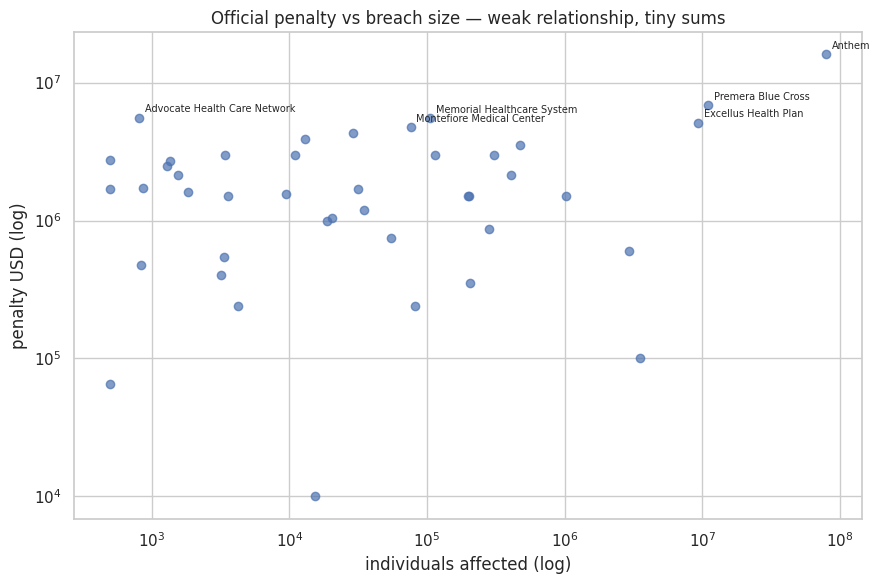

Spearman correlation (size vs penalty): 0.14
Median penalty per matched breach: $1,650,000
Anthem: $16M penalty for 78.8M records = $0.20 per record


In [5]:
m = matched.dropna(subset=["individuals_affected"])
m = m[m["individuals_affected"] > 0]
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(m["individuals_affected"], m["amount_usd"], alpha=0.7, color="#4C72B0")
for _, r in m.nlargest(6, "amount_usd").iterrows():
    ax.annotate(r["enforcement_entity"], (r["individuals_affected"], r["amount_usd"]),
                fontsize=7, xytext=(4, 4), textcoords="offset points")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("individuals affected (log)"); ax.set_ylabel("penalty USD (log)")
ax.set_title("Official penalty vs breach size — weak relationship, tiny sums")
plt.tight_layout(); plt.show()

corr = m[["individuals_affected", "amount_usd"]].corr(method="spearman").iloc[0, 1]
print(f"Spearman correlation (size vs penalty): {corr:.2f}")
print(f"Median penalty per matched breach: ${m['amount_usd'].median():,.0f}")
print(f"Anthem: $16M penalty for 78.8M records = ${16e6 / 78.8e6:.2f} per record")

## Findings

1. **Official penalties are rare and small relative to the problem**: the amount-stated subset
   totals ~$126M across 17 years — versus ~1.04 *billion* records breached. Anthem's record
   $16M settlement works out to **about 20 cents per breached record**.
2. **Penalty size correlates only weakly with breach size** — enforcement targets *compliance
   failures* found during investigation (no risk analysis, no encryption, no BAAs), not harm
   volume. Several six-figure penalties attach to breaches of under 2,000 people.
3. **Fewer than 1% of reported breaches result in a published financial penalty**
   (~40+ matched actions vs 7,795 breaches).
4. This is the only *non-estimated* dollar data in the project; everything else (the dashboard
   cost tab) remains benchmark-derived and labeled as such.